# House Prices — EDA, Cleaning & Deep Learning Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

## Load data

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_sub = pd.read_csv('sample_submission.csv')
train.shape, test.shape

((1460, 81), (1459, 80))

In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

## Missing values overview

In [4]:
na_counts = train.isna().sum()
na_counts = na_counts[na_counts > 0].sort_values(ascending=False)
na_counts

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

## Column type lists

In [5]:
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = train.select_dtypes(include=['int64','float64']).columns.tolist()
numeric_cols.remove('Id')
numeric_cols.remove('SalePrice')

# these are numeric dtype but semantically categorical
categorical_cols += ['MSSubClass', 'MoSold']
numeric_cols.remove('MSSubClass')
numeric_cols.remove('MoSold')

print(len(categorical_cols), 'categorical |', len(numeric_cols), 'numeric')

45 categorical | 34 numeric


## Countplots — categorical columns

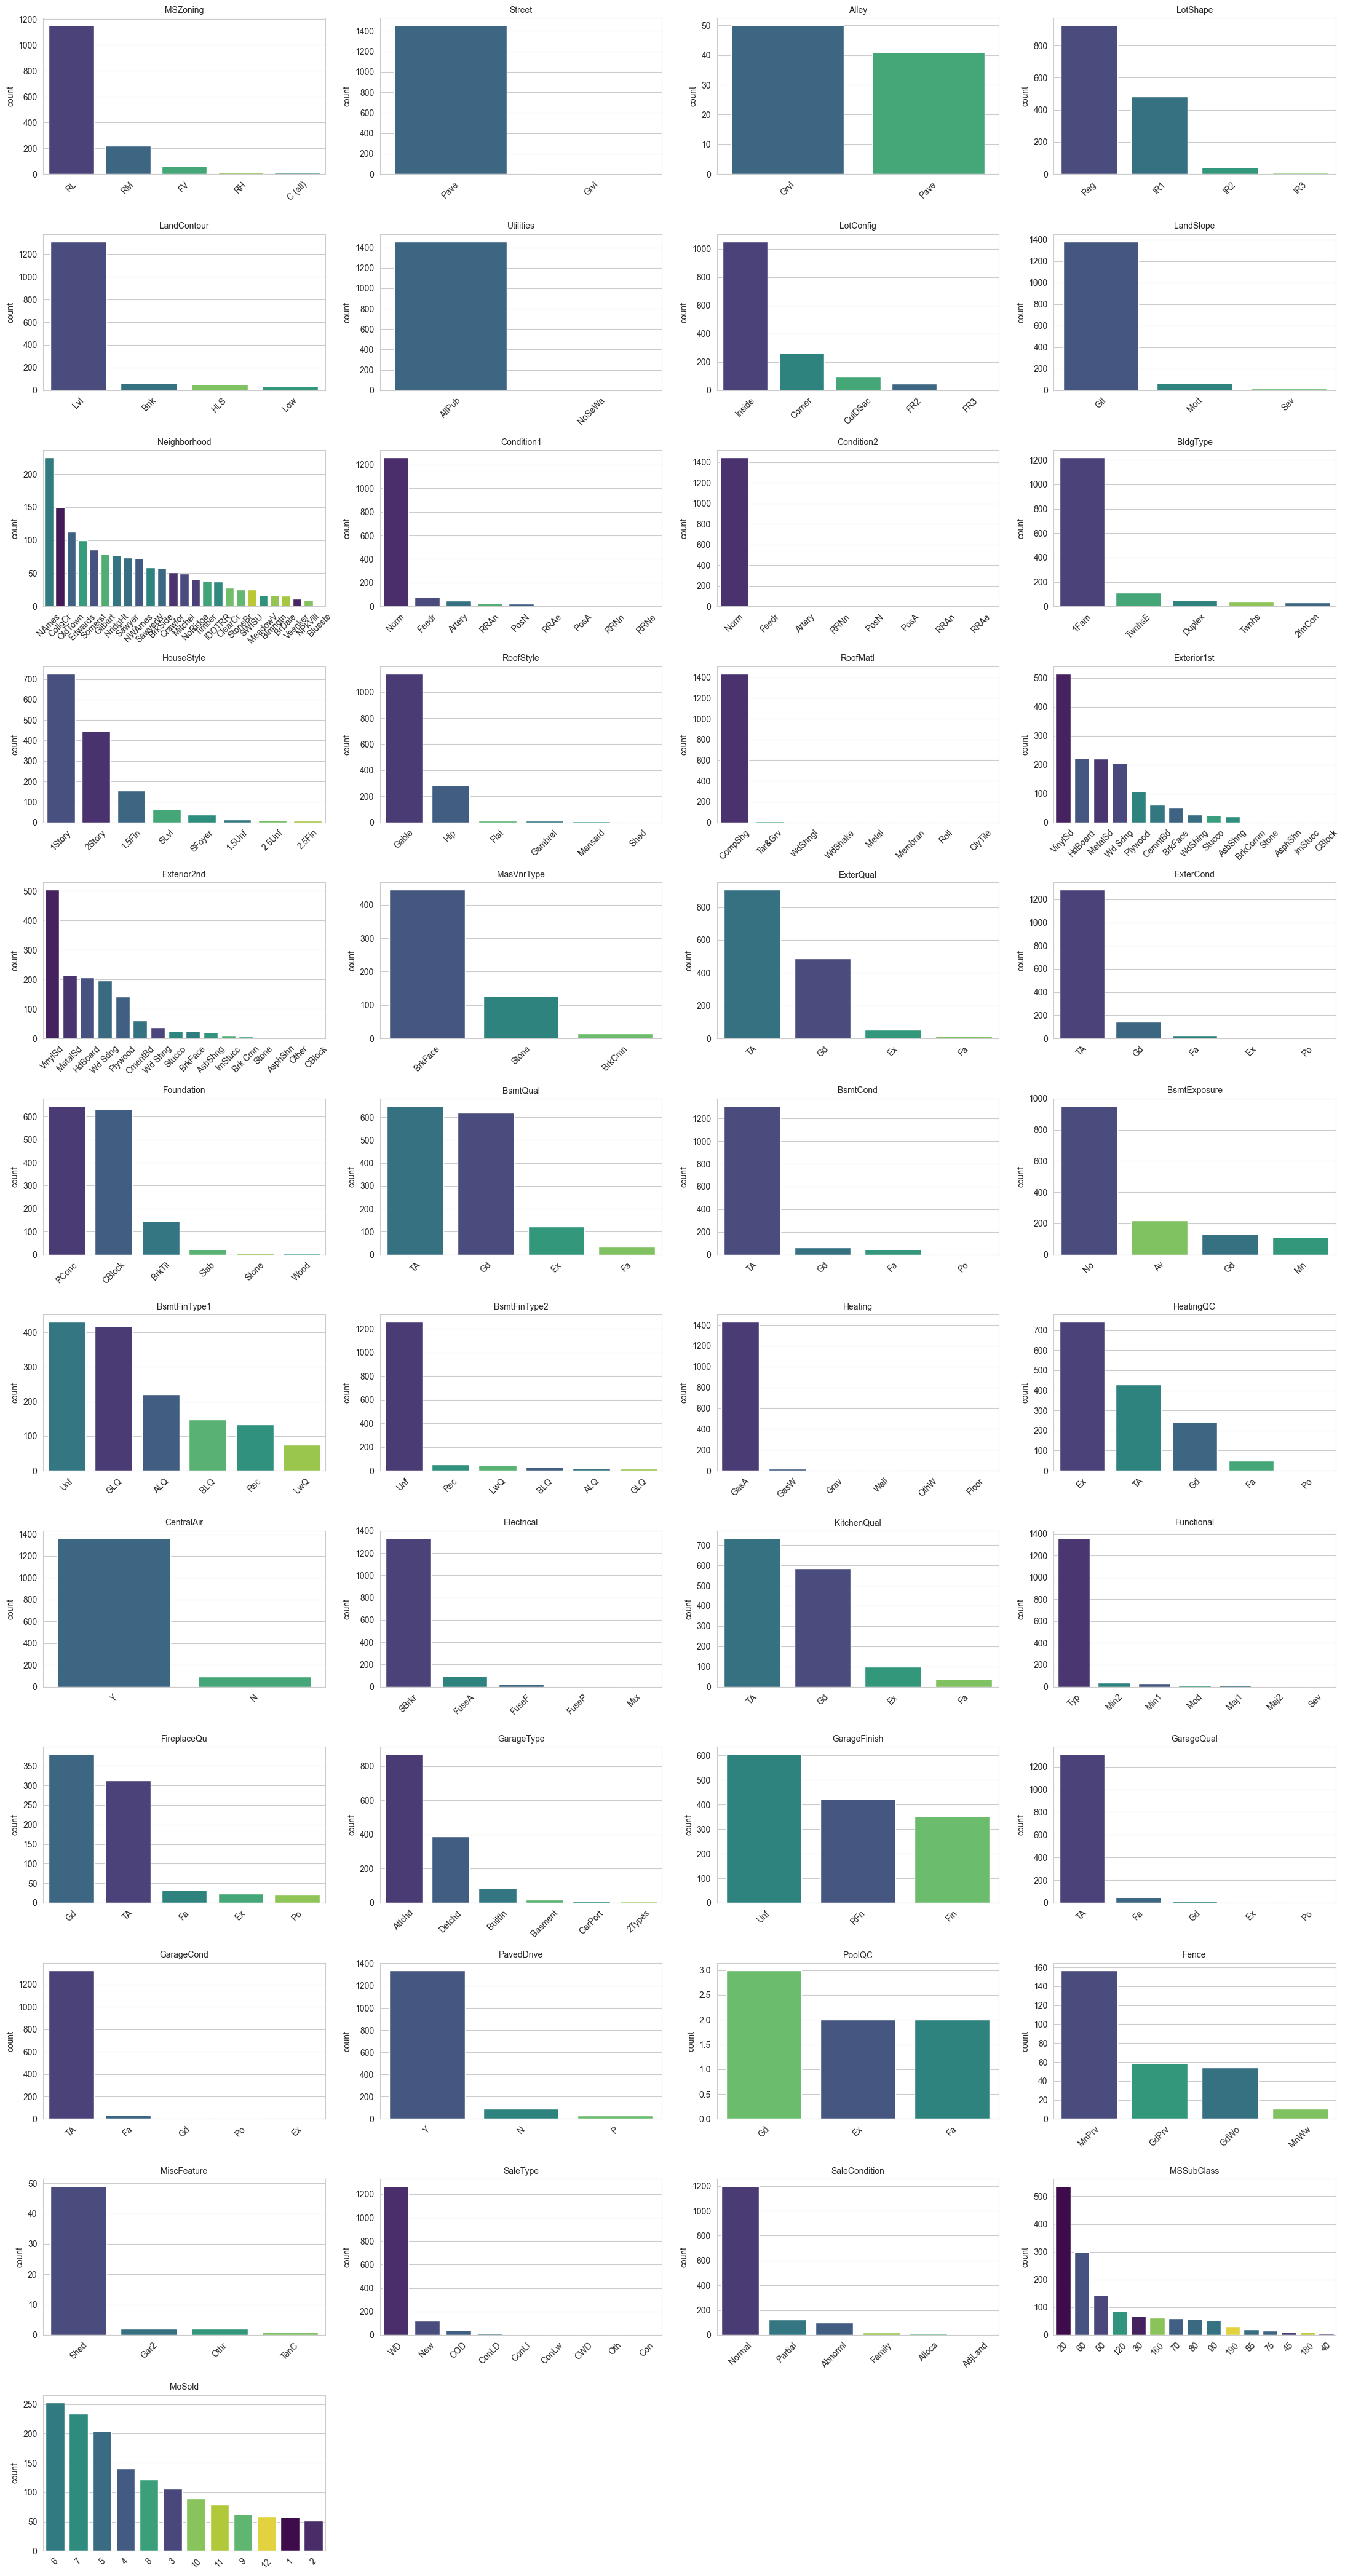

In [6]:
n_cat = len(categorical_cols)
ncols = 4
nrows = -(-n_cat // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = train[col].value_counts().index
    sns.countplot(data=train, x=col, order=order, hue=col, ax=axes[i], palette='viridis', legend=False)
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Histograms — numeric columns

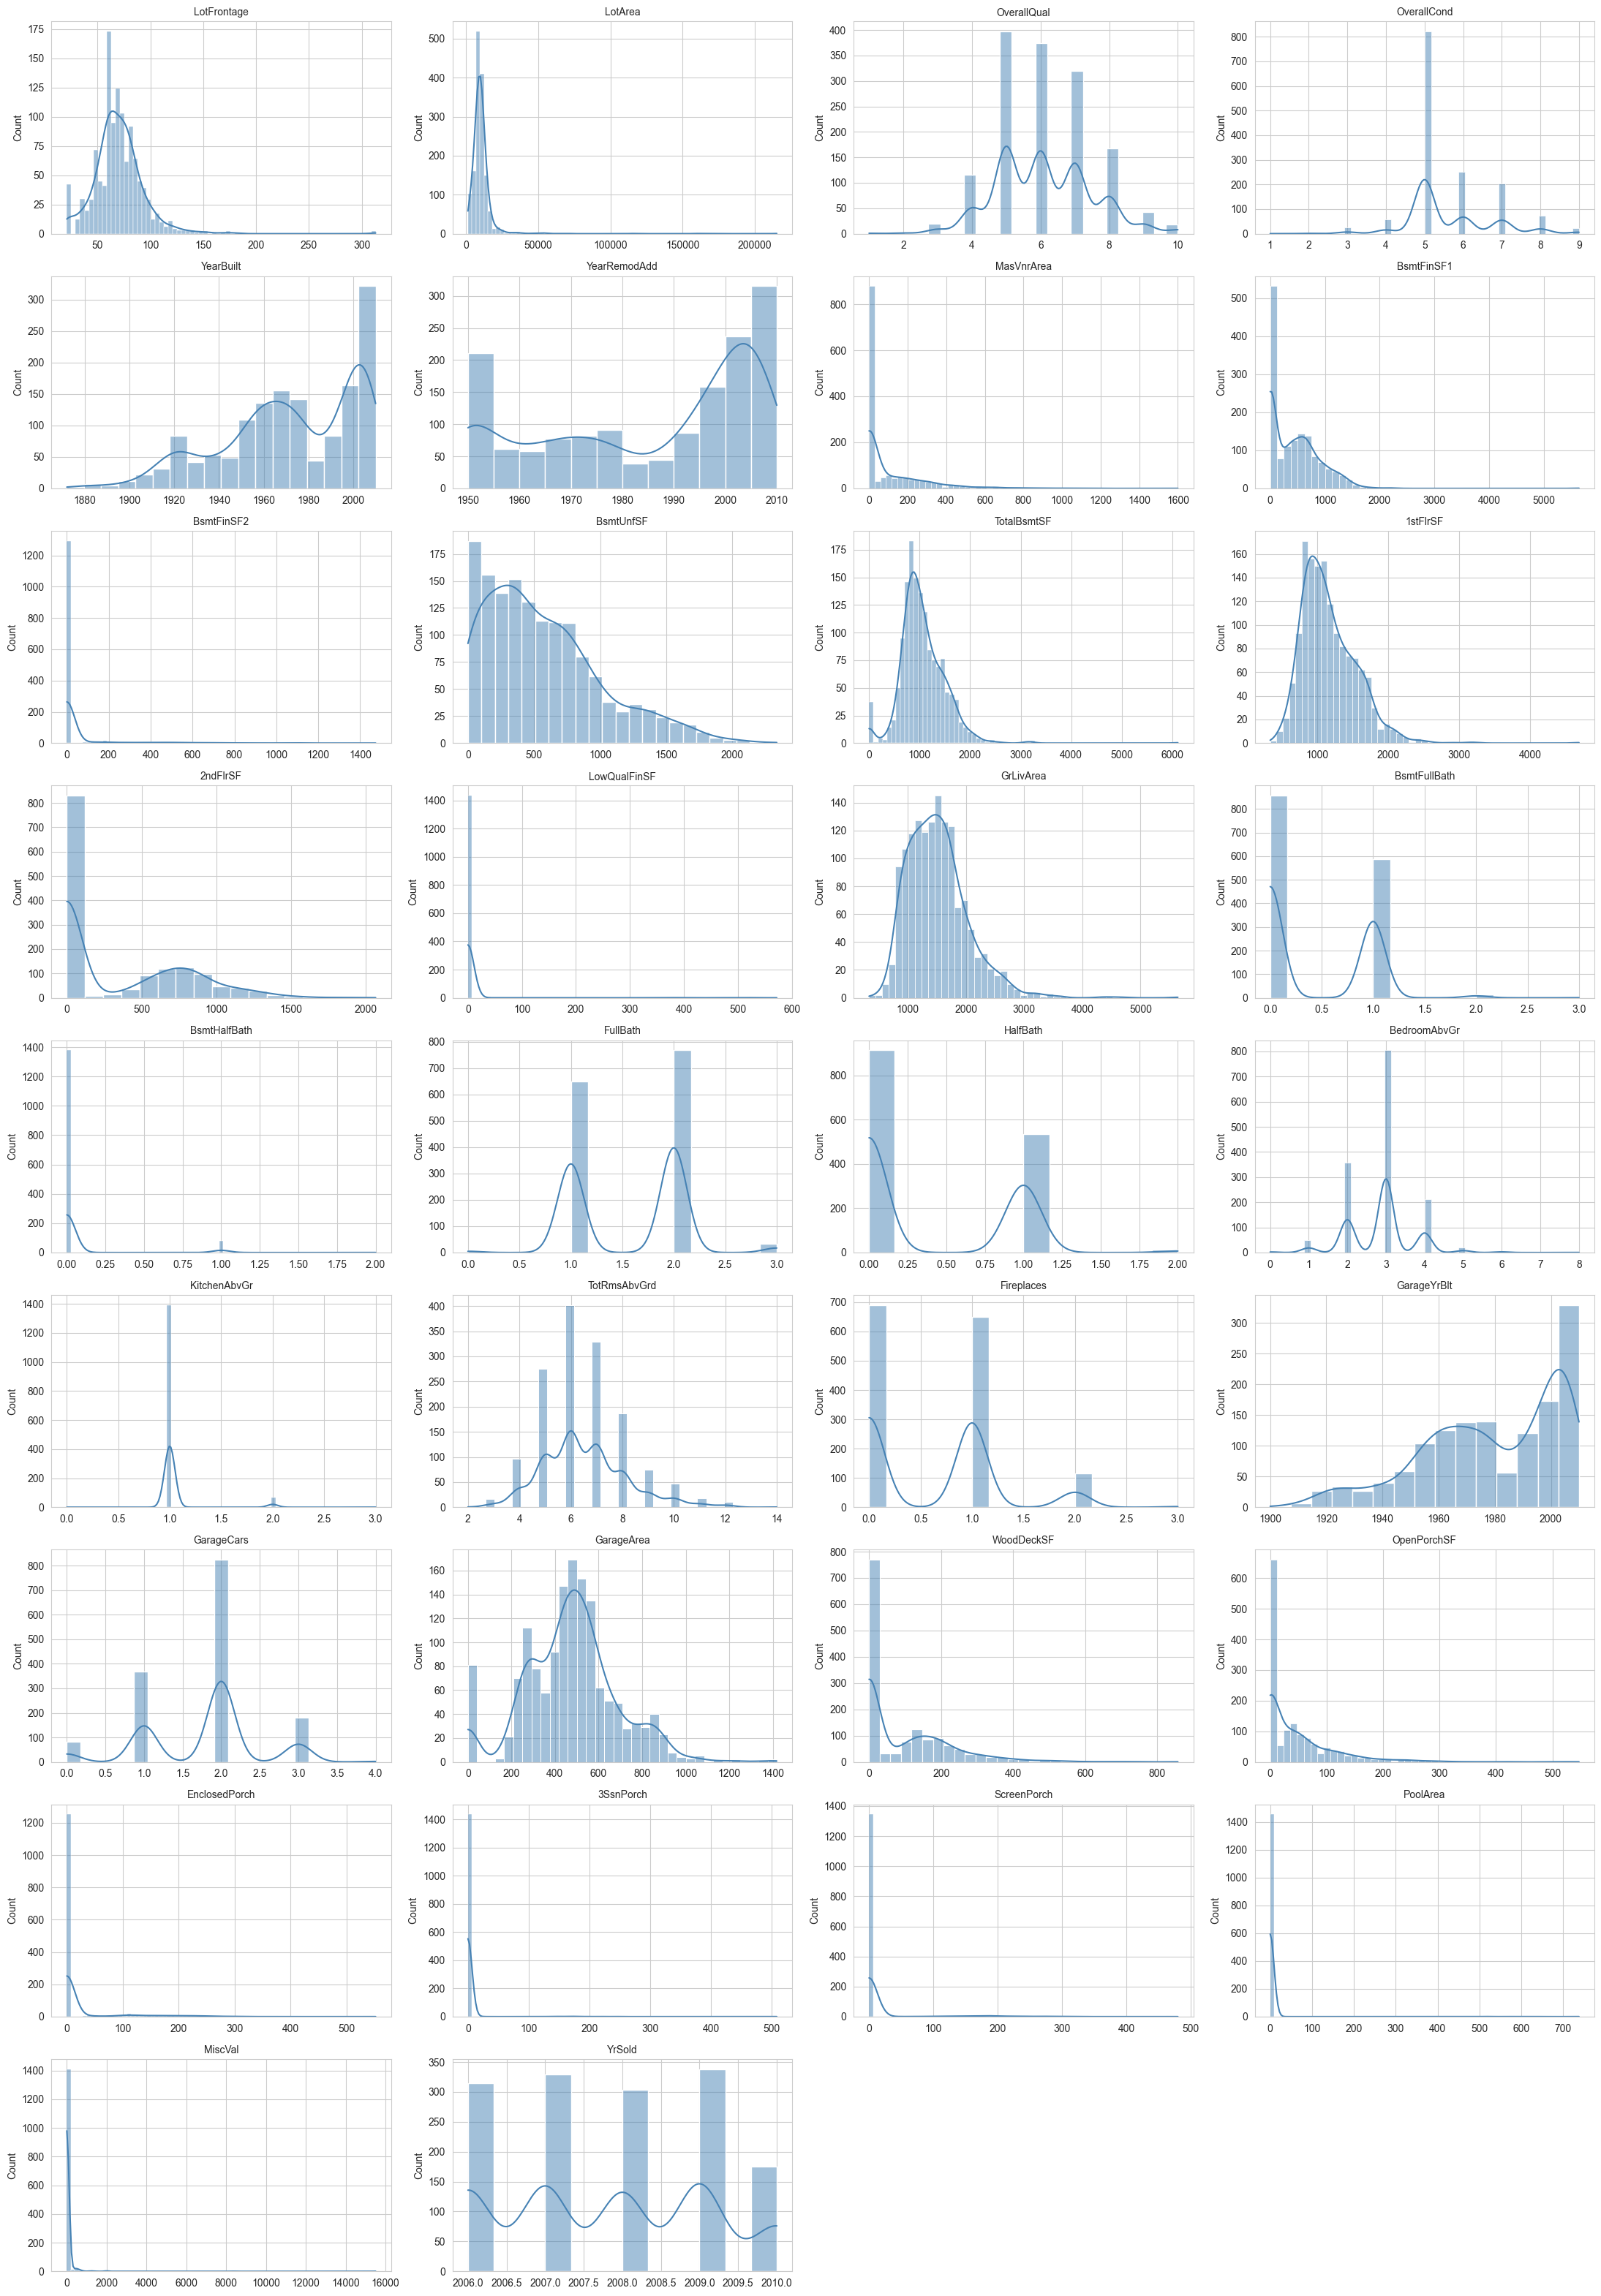

In [7]:
n_num = len(numeric_cols)
ncols = 4
nrows = -(-n_num // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(train[col].dropna(), kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Target distribution — SalePrice

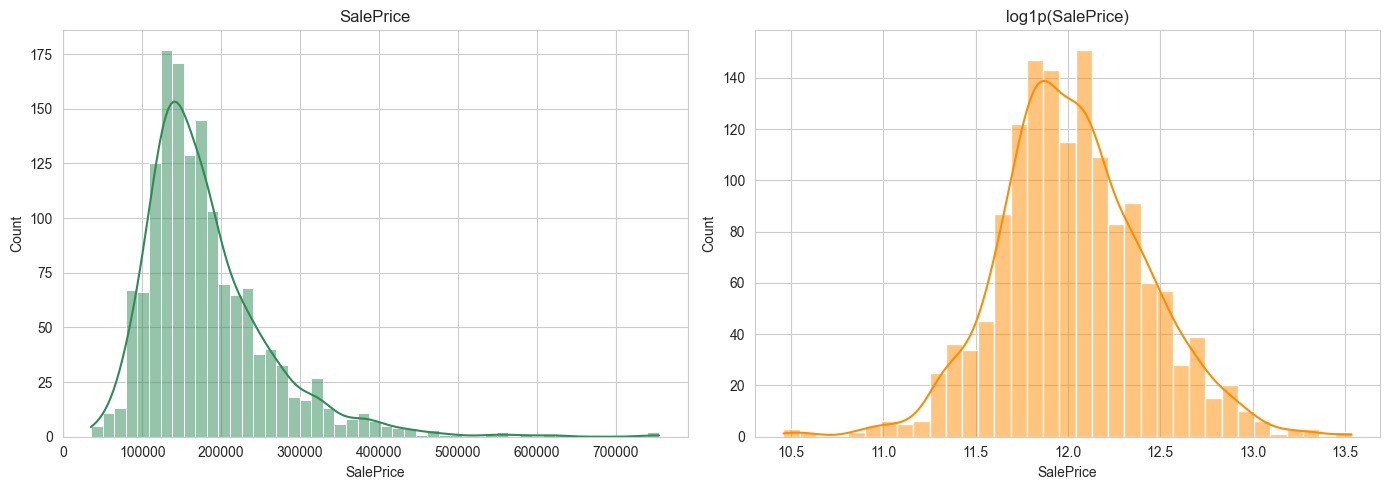

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train['SalePrice'], kde=True, ax=axes[0], color='seagreen')
axes[0].set_title('SalePrice')
sns.histplot(np.log1p(train['SalePrice']), kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('log1p(SalePrice)')
plt.tight_layout()
plt.show()

## Combine train + test for consistent cleaning

In [9]:
train_len = len(train)
test_ids = test['Id'].copy()
y = train['SalePrice'].copy()

df = pd.concat([train.drop(columns=['SalePrice']), test], axis=0, ignore_index=True)
df.shape

(2919, 80)

## Handle missing values\nMost NA in this dataset means the feature simply doesn't exist on the property (confirmed against related columns), so those are filled with `'None'`/`0` rather than imputed.

In [10]:
none_fill_cols = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
                  'GarageType','GarageFinish','GarageQual','GarageCond',
                  'BsmtExposure','BsmtFinType2','BsmtQual','BsmtCond','BsmtFinType1',
                  'MasVnrType']
for c in none_fill_cols:
    df[c] = df[c].fillna('None')

df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

zero_fill_cols = ['GarageCars','GarageArea','BsmtFullBath','BsmtHalfBath',
                   'BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF']
for c in zero_fill_cols:
    df[c] = df[c].fillna(0)

mode_fill_cols = ['MSZoning','Utilities','Exterior1st','Exterior2nd','Electrical',
                   'KitchenQual','Functional','SaleType']
for c in mode_fill_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

df.isna().sum().sum()

np.int64(0)

## Fix data types\n`MSSubClass` and `MoSold` are numeric codes, not real quantities — convert to categorical.

In [11]:
df['MSSubClass'] = df['MSSubClass'].astype(str)
df['MoSold'] = df['MoSold'].astype(str)
df['GarageYrBlt'] = df['GarageYrBlt'].astype(int)

## Feature engineering

In [12]:
df['HouseAge'] = df['YrSold'].astype(int) - df['YearBuilt']
df['YearsSinceRemod'] = df['YrSold'].astype(int) - df['YearRemodAdd']
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
for c in ['HouseAge', 'YearsSinceRemod']:
    df[c] = df[c].clip(lower=0)

## Encode categorical columns

In [13]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include='object').columns.tolist()
for c in cat_cols:
    df[c] = LabelEncoder().fit_transform(df[c])

df = df.drop(columns=['Id'])
df.shape

(2919, 82)

## Split back into train/test and scale

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train_full = df.iloc[:train_len].reset_index(drop=True)
X_test_final = df.iloc[train_len:].reset_index(drop=True)
y_log = np.log1p(y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test_final)

X_tr, X_val, y_tr, y_val = train_test_split(X_train_scaled, y_log, test_size=0.15, random_state=42)
X_tr.shape, X_val.shape

((1241, 82), (219, 82))

## Build deep learning model

In [15]:
import tensorflow as tf
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_tr.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
model.summary()

ModuleNotFoundError: No module named 'tensorflow'

## Train

In [16]:
early_stop = tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

print('Final val loss (MSE on log target):', history.history['val_loss'][-1])
print('Final val MAE (log target):', history.history['val_mae'][-1])

Final val loss (MSE on log target): 0.0418073795735836
Final val MAE (log target): 0.1407933086156845


## Training curves

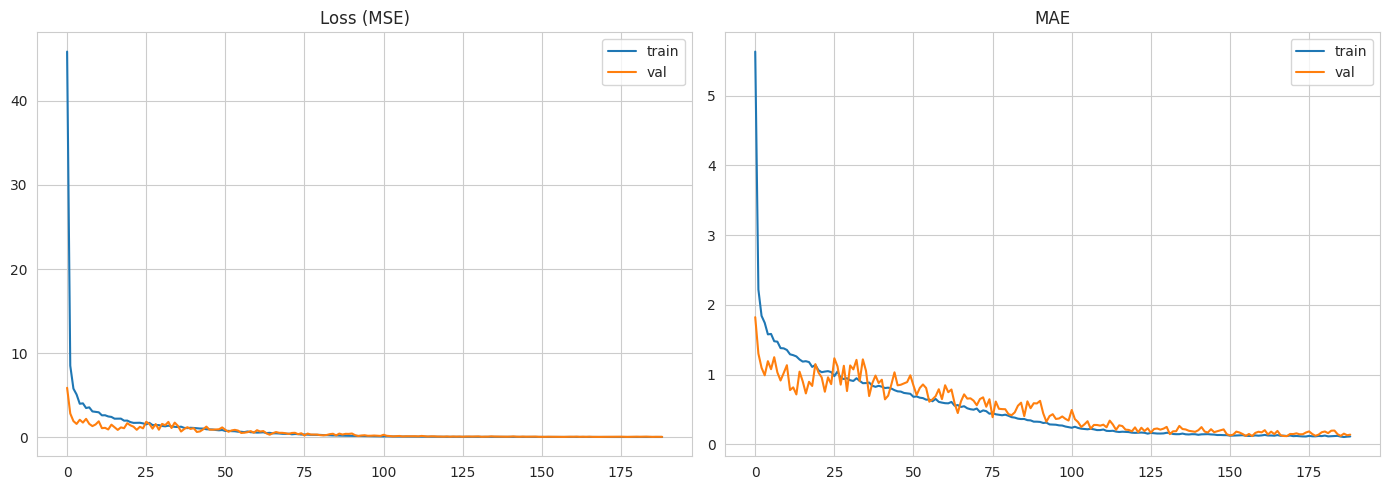

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss (MSE)')
axes[0].legend()

axes[1].plot(history.history['mae'], label='train')
axes[1].plot(history.history['val_mae'], label='val')
axes[1].set_title('MAE')
axes[1].legend()
plt.tight_layout()
plt.show()

## Validate — RMSE in actual dollars

In [18]:
from sklearn.metrics import mean_squared_error

val_preds_log = model.predict(X_val, verbose=0).flatten()
val_preds = np.expm1(val_preds_log)
val_actual = np.expm1(y_val)

rmse = np.sqrt(mean_squared_error(val_actual, val_preds))
print(f'Validation RMSE: ${rmse:,.2f}')

Validation RMSE: $40,755.29


## Predict on test set & build submission.csv

In [19]:
test_preds_log = model.predict(X_test_scaled, verbose=0).flatten()
test_preds = np.expm1(test_preds_log)

submission = pd.DataFrame({'Id': test_ids, 'SalePrice': test_preds})
submission.to_csv('submission.csv', index=False)
submission.head()

,Id,SalePrice
0,1461,113619.398438
1,1462,128505.507812
2,1463,177967.890625
3,1464,192531.125000
4,1465,188752.859375
